# 🏭 ML Factory - Entraînement de Modèles Iris

Ce notebook permet d'entraîner et de déployer des modèles de classification Iris avec **MLflow** et **Zero-Downtime**.

## 🎯 Objectifs

1. Explorer le dataset Iris
2. Entraîner différents modèles (Logistic Regression, Random Forest)
3. Comparer les performances
4. Enregistrer les modèles dans MLflow
5. Promouvoir le meilleur modèle en Production

---

## 📦 Configuration et Imports

In [20]:
import os
import pathlib
from dotenv import load_dotenv
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## ⚙️ Configuration MLflow

In [ ]:
# Charger les variables d'environnement
# Utiliser un chemin absolu basé sur le répertoire du notebook
notebook_dir = pathlib.Path.cwd() if "notebooks" in str(pathlib.Path.cwd()) else pathlib.Path(__file__).parent.resolve()
print(f"📂 Répertoire de travail: {pathlib.Path.cwd()}")

env_local_path = pathlib.Path("../.env.local").resolve()
env_path = pathlib.Path("../.env").resolve()

print(f"🔍 Recherche de .env.local: {env_local_path}")
print(f"🔍 Existe? {env_local_path.exists()}")

if env_local_path.exists():
    load_dotenv(env_local_path, override=True)
    print(f"✅ Configuration chargée depuis: {env_local_path}")
else:
    load_dotenv(env_path, override=True)
    print(f"✅ Configuration chargée depuis: {env_path}")

# Configuration MLflow
# Option 1: Stockage local (pour tests sans serveur MLflow)
# mlflow.set_tracking_uri("file:../mlruns")

# Option 2: Serveur MLflow distant (Docker Compose démarré)
# IMPORTANT: Pour notebook local, utiliser localhost (pas 'mlflow' qui est pour Docker)
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000")

# Si l'URI contient 'mlflow' (hostname Docker), remplacer par localhost
if "mlflow:" in MLFLOW_TRACKING_URI:
    MLFLOW_TRACKING_URI = MLFLOW_TRACKING_URI.replace("http://mlflow:", "http://localhost:")
    print(f"⚠️  URI Docker détectée, conversion en localhost")

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID", "minioadmin")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY", "minioadmin")

# MinIO endpoint: utiliser localhost pour notebook local
MLFLOW_S3_ENDPOINT_URL = os.getenv("MLFLOW_S3_ENDPOINT_URL", "http://localhost:9000")
if "minio:" in MLFLOW_S3_ENDPOINT_URL:
    MLFLOW_S3_ENDPOINT_URL = MLFLOW_S3_ENDPOINT_URL.replace("http://minio:", "http://localhost:")
    print(f"⚠️  MinIO Docker détecté, conversion en localhost")

os.environ["MLFLOW_S3_ENDPOINT_URL"] = MLFLOW_S3_ENDPOINT_URL
os.environ["MLFLOW_S3_IGNORE_TLS"] = "true"

MODEL_NAME = os.getenv("MODEL_NAME", "iris_classifier")
AUTO_PROMOTE = True  # Mettre à False pour promotion manuelle

print(f"\n✅ MLflow configuré: {MLFLOW_TRACKING_URI}")
print(f"✅ MinIO endpoint: {MLFLOW_S3_ENDPOINT_URL}")
print(f"✅ Modèle: {MODEL_NAME}")
print(f"✅ Promotion auto: {AUTO_PROMOTE}")

# Créer l'expérience MLflow
mlflow.set_experiment("iris_classification")

📝 Configuration chargée depuis: ..\.env.local


MlflowException: API request to http://mlflow:5000/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPConnectionPool(host='mlflow', port=5000): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=iris_classification (Caused by NameResolutionError("HTTPConnection(host='mlflow', port=5000): Failed to resolve 'mlflow' ([Errno 11001] getaddrinfo failed)"))

## 📊 Exploration du Dataset Iris

In [5]:
# Charger les données
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")
target_names = iris.target_names

print(f"📊 Dataset Iris chargé:")
print(f"   - Échantillons: {len(X)}")
print(f"   - Features: {X.shape[1]}")
print(f"   - Classes: {len(target_names)} ({', '.join(target_names)})")

# Afficher les premières lignes
df = X.copy()
df['target'] = y
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head(10)

📊 Dataset Iris chargé:
   - Échantillons: 150
   - Features: 4
   - Classes: 3 (setosa, versicolor, virginica)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


In [6]:
# Statistiques descriptives
print("📈 Statistiques descriptives:")
X.describe()

📈 Statistiques descriptives:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


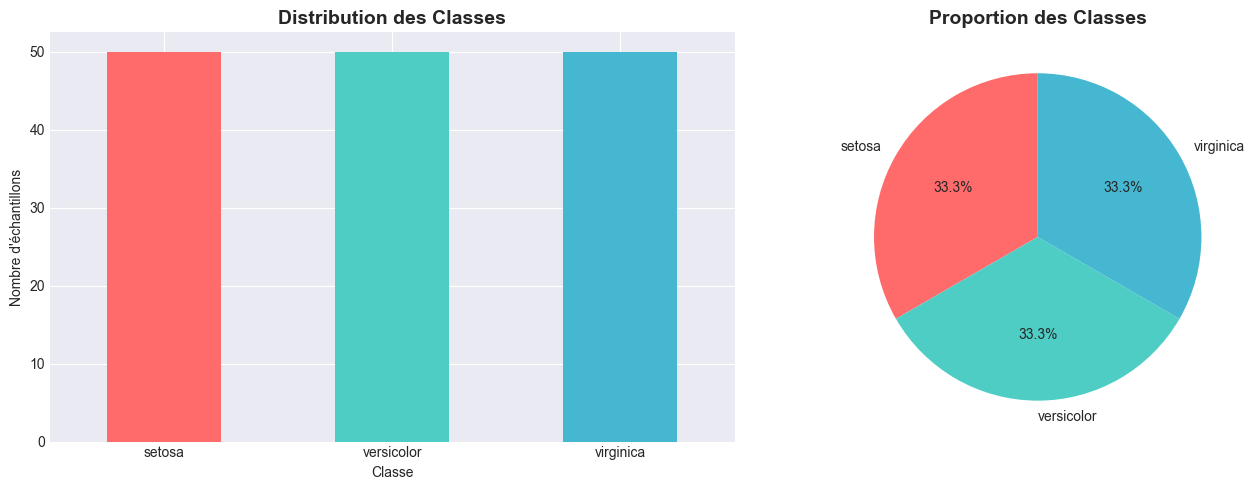

✅ Dataset équilibré (33.3% pour chaque classe)


In [7]:
# Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
y.value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Distribution des Classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre d\'échantillons')
axes[0].set_xticklabels(target_names, rotation=0)

# Camembert
axes[1].pie(y.value_counts(), labels=target_names, autopct='%1.1f%%', 
            colors=['#FF6B6B', '#4ECDC4', '#45B7D1'], startangle=90)
axes[1].set_title('Proportion des Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Dataset équilibré (33.3% pour chaque classe)")

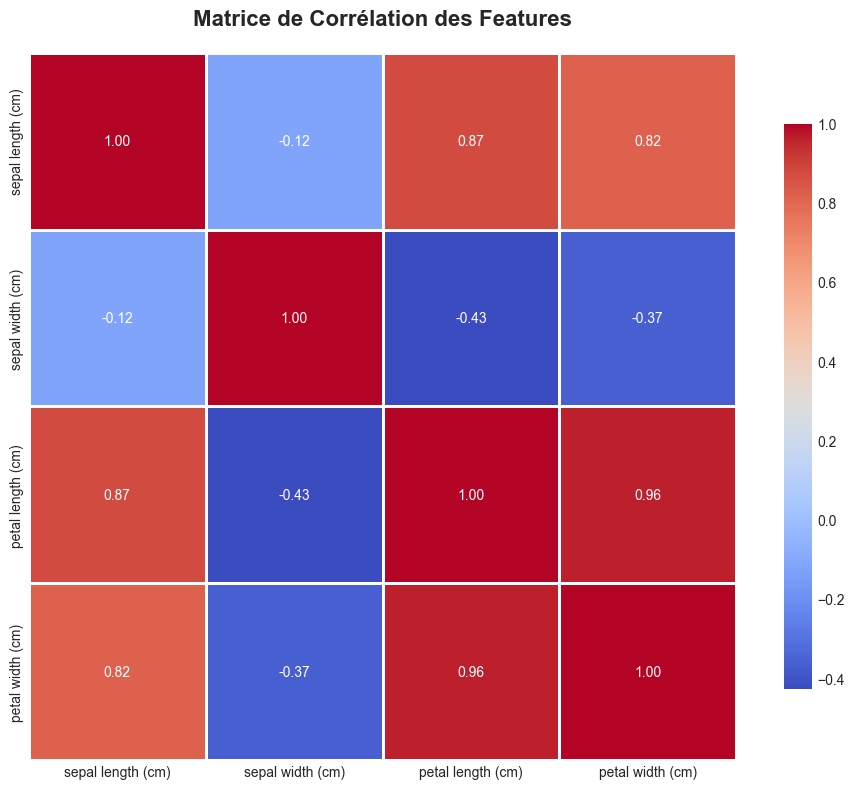

In [8]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation des Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

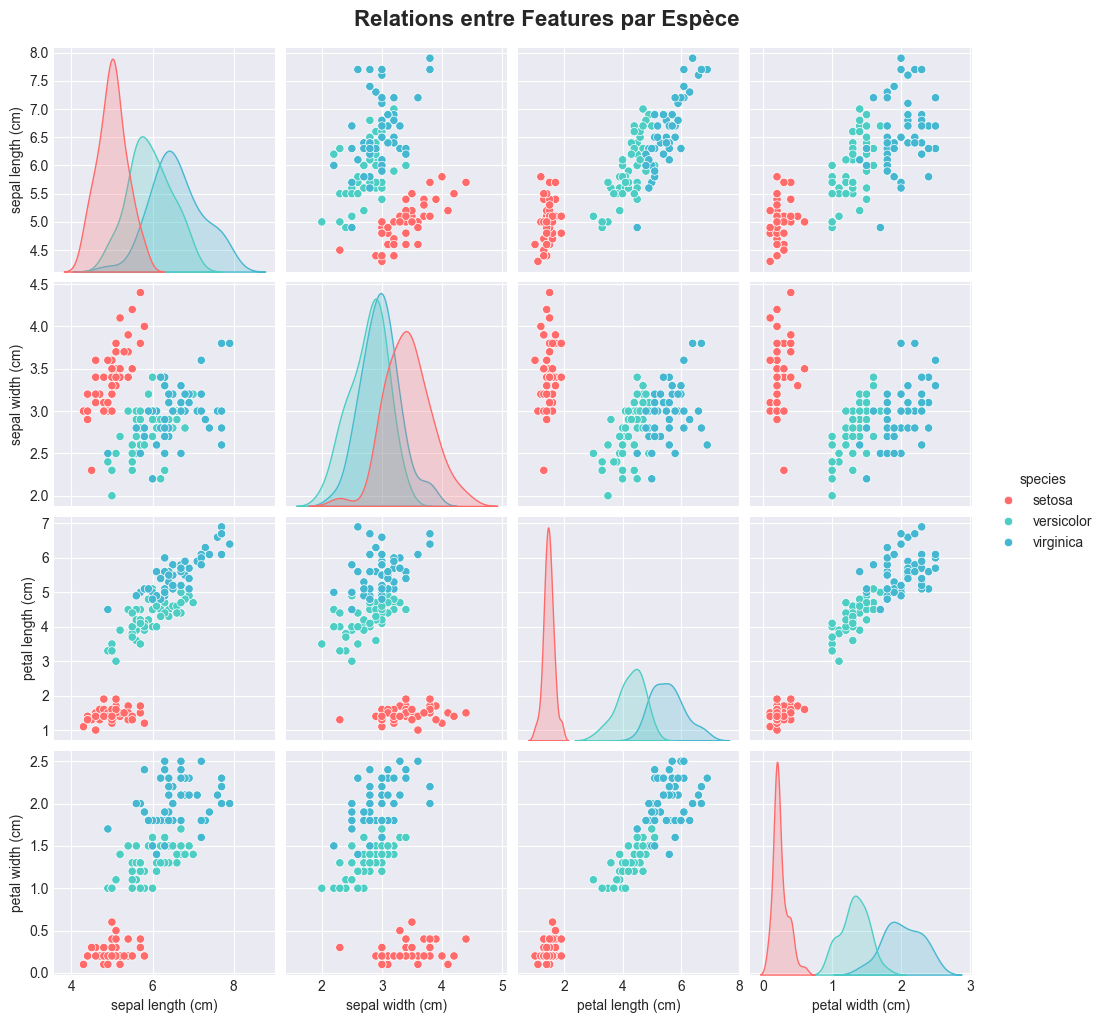

In [9]:
# Pairplot pour visualiser les relations
df_viz = X.copy()
df_viz['species'] = y.map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
sns.pairplot(df_viz, hue='species', palette=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
             diag_kind='kde', height=2.5)
plt.suptitle('Relations entre Features par Espèce', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## 🔀 Préparation des Données

In [ ]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Données divisées:")
print(f"   - Train: {len(X_train)} échantillons ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Test:  {len(X_test)} échantillons ({len(X_test)/len(X)*100:.1f}%)")

# Sauvegarder un fichier de test pour le frontend
X_test_sample = X.sample(n=10, random_state=42)
y_test_sample = y.loc[X_test_sample.index]
test_df = X_test_sample.copy()
test_df["target"] = y_test_sample

os.makedirs("../data", exist_ok=True)
test_df.to_csv("../data/iris_test.csv", index=False)
print(f"\n✅ Fichier de test sauvegardé: ../data/iris_test.csv")

✅ Données divisées:
   - Train: 120 échantillons (80.0%)
   - Test:  30 échantillons (20.0%)

✅ Fichier de test sauvegardé: ../../data/iris_test.csv


## 🤖 Entraînement des Modèles

### Modèle 1: Logistic Regression

In [11]:
def train_and_evaluate(model, model_name, params):
    """Entraîne un modèle et enregistre les métriques dans MLflow."""
    
    with mlflow.start_run(run_name=f"{model_name}_training") as run:
        print(f"\n{'='*60}")
        print(f"🚀 Entraînement: {model_name}")
        print(f"🔬 Run ID: {run.info.run_id}")
        print(f"{'='*60}")
        
        # Entraînement
        model.fit(X_train, y_train)
        
        # Prédictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # Métriques
        metrics = {
            "train_accuracy": accuracy_score(y_train, y_pred_train),
            "test_accuracy": accuracy_score(y_test, y_pred_test),
            "test_f1": f1_score(y_test, y_pred_test, average="weighted"),
            "test_precision": precision_score(y_test, y_pred_test, average="weighted"),
            "test_recall": recall_score(y_test, y_pred_test, average="weighted")
        }
        
        # Log dans MLflow
        mlflow.log_params(params)
        mlflow.log_param("model_type", model_name)
        mlflow.log_metrics(metrics)
        
        # Enregistrer le modèle
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model"
        )
        
        # Affichage des résultats
        print(f"\n📊 Métriques:")
        print(f"   - Train Accuracy:  {metrics['train_accuracy']:.4f}")
        print(f"   - Test Accuracy:   {metrics['test_accuracy']:.4f}")
        print(f"   - F1-Score:        {metrics['test_f1']:.4f}")
        print(f"   - Precision:       {metrics['test_precision']:.4f}")
        print(f"   - Recall:          {metrics['test_recall']:.4f}")
        
        # Matrice de confusion
        cm = confusion_matrix(y_test, y_pred_test)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=target_names, yticklabels=target_names)
        plt.title(f'Matrice de Confusion - {model_name}', fontsize=14, fontweight='bold')
        plt.ylabel('Réel')
        plt.xlabel('Prédit')
        plt.tight_layout()
        plt.show()
        
        # Rapport de classification
        print(f"\n📋 Rapport de Classification:")
        print(classification_report(y_test, y_pred_test, target_names=target_names))
        
        return run.info.run_id, metrics


🚀 Entraînement: logistic_regression
🔬 Run ID: 4b90f5e13c26474a9999a7bd5478a0d9


2026/03/17 12:33:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



📊 Métriques:
   - Train Accuracy:  0.9750
   - Test Accuracy:   0.9667
   - F1-Score:        0.9666
   - Precision:       0.9697
   - Recall:          0.9667


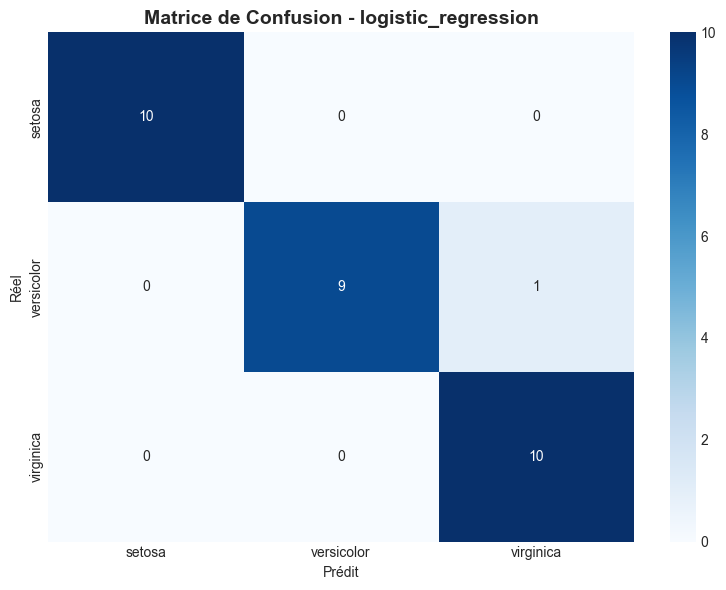


📋 Rapport de Classification:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [12]:
# Entraîner Logistic Regression
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_params = {"max_iter": 200, "solver": "lbfgs"}

lr_run_id, lr_metrics = train_and_evaluate(lr_model, "logistic_regression", lr_params)

### Modèle 2: Random Forest


🚀 Entraînement: random_forest
🔬 Run ID: 0c44f37d999e408e84143c43199c3c29


2026/03/17 12:33:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



📊 Métriques:
   - Train Accuracy:  1.0000
   - Test Accuracy:   0.9333
   - F1-Score:        0.9333
   - Precision:       0.9333
   - Recall:          0.9333


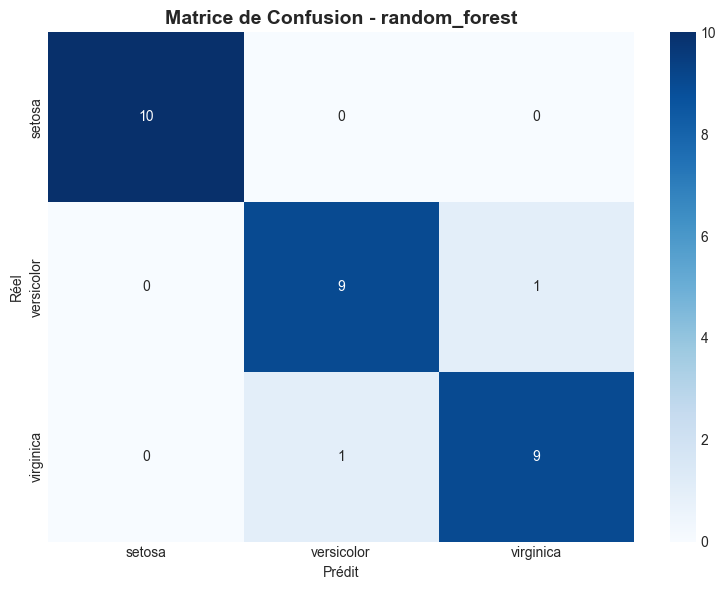


📋 Rapport de Classification:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [13]:
# Entraîner Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_params = {"n_estimators": 100, "max_depth": 5}

rf_run_id, rf_metrics = train_and_evaluate(rf_model, "random_forest", rf_params)

## 📊 Comparaison des Modèles

🔍 Comparaison des Modèles:

                     train_accuracy  test_accuracy   test_f1  test_precision  \
Logistic Regression           0.975       0.966667  0.966583        0.969697   
Random Forest                 1.000       0.933333  0.933333        0.933333   

                     test_recall  
Logistic Regression     0.966667  
Random Forest           0.933333  


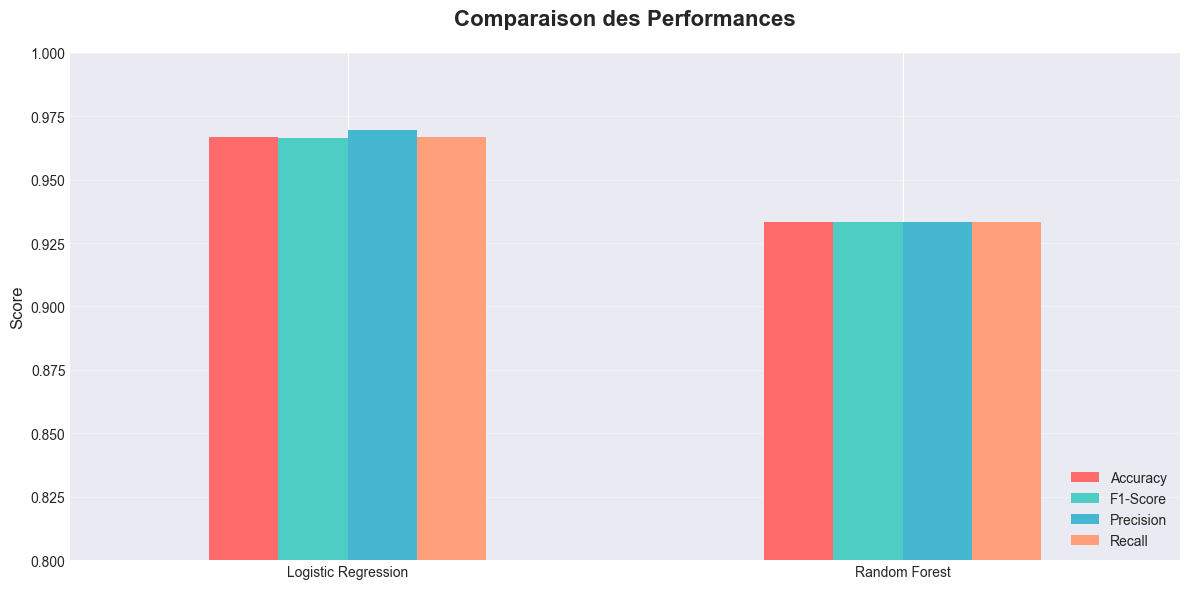


🏆 Meilleur modèle: Logistic Regression
   Run ID: 4b90f5e13c26474a9999a7bd5478a0d9


In [14]:
# Comparer les performances
comparison = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics
}).T

print("🔍 Comparaison des Modèles:\n")
print(comparison)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
comparison[['test_accuracy', 'test_f1', 'test_precision', 'test_recall']].plot(
    kind='bar', ax=ax, rot=0, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
)
ax.set_title('Comparaison des Performances', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim([0.8, 1.0])
ax.legend(['Accuracy', 'F1-Score', 'Precision', 'Recall'], loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Déterminer le meilleur modèle
best_model = 'Random Forest' if rf_metrics['test_accuracy'] > lr_metrics['test_accuracy'] else 'Logistic Regression'
best_run_id = rf_run_id if best_model == 'Random Forest' else lr_run_id

print(f"\n🏆 Meilleur modèle: {best_model}")
print(f"   Run ID: {best_run_id}")

## 🚀 Enregistrement et Promotion dans MLflow Model Registry

In [15]:
def register_and_promote_model(run_id, model_name, auto_promote=True):
    """Enregistre un modèle et le promeut en Production."""
    
    client = MlflowClient()
    model_uri = f"runs:/{run_id}/model"
    
    # Créer ou obtenir le registered model
    try:
        client.create_registered_model(model_name)
        print(f"✅ Modèle '{model_name}' créé dans le registre")
    except Exception:
        print(f"ℹ️  Modèle '{model_name}' existe déjà")
    
    # Créer une nouvelle version
    model_version = client.create_model_version(
        name=model_name,
        source=model_uri,
        run_id=run_id
    )
    
    version_number = model_version.version
    print(f"✅ Version {version_number} créée")
    
    # Promotion automatique ou manuelle
    if auto_promote:
        client.set_registered_model_alias(
            name=model_name,
            alias="Production",
            version=version_number
        )
        print(f"\n🎉 Modèle v{version_number} PROMU EN PRODUCTION (alias 'Production')")
        print(f"   → L'API va recharger automatiquement le nouveau modèle!")
    else:
        print(f"\n⏸️  Modèle v{version_number} enregistré (mode manuel)")
        print(f"   → Rendez-vous sur MLflow UI pour promouvoir manuellement")
        print(f"   → http://localhost:5000/#/models/{model_name}")
    
    return version_number

In [16]:
# Enregistrer le meilleur modèle
print(f"\n📦 Enregistrement du meilleur modèle: {best_model}\n")
print(f"{'='*60}")

version = register_and_promote_model(
    run_id=best_run_id,
    model_name=MODEL_NAME,
    auto_promote=AUTO_PROMOTE
)

print(f"{'='*60}")


📦 Enregistrement du meilleur modèle: Logistic Regression

✅ Modèle 'iris_classifier' créé dans le registre
✅ Version 1 créée

🎉 Modèle v1 PROMU EN PRODUCTION (alias 'Production')
   → L'API va recharger automatiquement le nouveau modèle!


## 🔍 Vérification de l'API *(optionnel - nécessite Docker)*

⚠️ **Note**: Cette section nécessite que Docker Compose soit démarré avec `docker-compose up -d`.  
Si vous utilisez MLflow en mode local, vous pouvez ignorer cette cellule et passer à la section suivante.

In [19]:
# ⚠️ OPTIONNEL: Nécessite Docker Compose démarré
# Pour démarrer: docker-compose up -d
# Pour ce test local, vous pouvez ignorer cette cellule

import requests
import time

API_URL = "http://localhost:8000"

# Attendre que l'API recharge le modèle
print("⏳ Attente de 5 secondes pour le rechargement...")
time.sleep(5)

# Vérifier la version actuelle
try:
    response = requests.get(f"{API_URL}/model-info")
    if response.status_code == 200:
        model_info = response.json()
        print(f"\n✅ API utilise actuellement:")
        print(f"   - Version: {model_info['version']}")
        print(f"   - Run ID: {model_info['run_id']}")
        print(f"\n🎉 Zero-Downtime fonctionnel!")
    else:
        print(f"⚠️  API non accessible (code {response.status_code})")
except Exception as e:
    print(f"ℹ️  API non démarrée (normal en mode local)")
    print(f"   Pour utiliser l'API: docker-compose up -d")

⏳ Attente de 5 secondes pour le rechargement...

✅ API utilise actuellement:
ℹ️  API non démarrée (normal en mode local)
   Pour utiliser l'API: docker-compose up -d


## 🌐 Test de Prédiction *(optionnel - nécessite Docker)*

⚠️ **Note**: Cette section nécessite également que l'API Docker soit démarrée.  
En mode local, utilisez directement le modèle chargé depuis MLflow pour faire des prédictions.

In [ ]:
# ⚠️ OPTIONNEL: Nécessite Docker Compose démarré
# Pour ce test local, vous pouvez ignorer cette cellule

# Tester une prédiction
test_sample = {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
}

try:
    response = requests.post(f"{API_URL}/predict", json=test_sample)
    if response.status_code == 200:
        result = response.json()
        print(f"\n🔮 Prédiction pour l'échantillon test:")
        print(f"   Input: {test_sample}")
        print(f"\n   Classe prédite: {result['predicted_class']} ({result['class_name']})")
        print(f"   Confiance: {max(result['probabilities'].values()):.2%}")
        print(f"\n   Probabilités:")
        for cls, prob in result['probabilities'].items():
            print(f"      - {cls}: {prob:.2%}")
        print(f"\n   Modèle utilisé: v{result['model_version']}")
except Exception as e:
    print(f"ℹ️  API non démarrée (normal en mode local)")
    print(f"   Pour utiliser l'API: docker-compose up -d")

## 📌 Résumé

### ✅ Ce qui a été fait:

1. ✅ Exploration du dataset Iris
2. ✅ Entraînement de 2 modèles (Logistic Regression, Random Forest)
3. ✅ Comparaison des performances
4. ✅ Enregistrement dans MLflow Model Registry
5. ✅ Promotion automatique/manuelle en Production
6. ✅ Vérification du Zero-Downtime

### 🎯 Prochaines étapes:

- Ouvrir Streamlit: http://localhost:8501
- Vérifier MLflow UI: http://localhost:5000
- Tester l'API: http://localhost:8000/docs

### 🔄 Pour entraîner un nouveau modèle:

1. Modifier `AUTO_PROMOTE = False` pour le mode manuel
2. Relancer les cellules d'entraînement
3. Promouvoir manuellement dans MLflow UI
4. Observer le changement sans downtime ! 🚀